In [2]:
# Cell 1 — Installs + Imports
!pip install transformers torch spacy openpyxl -q
!python -m spacy download en_core_web_sm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import spacy
import os
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax

print('All imports successful!')
print(f'torch version: {torch.__version__}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 111.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All imports successful!
torch version: 2.10.0+cu128


In [3]:
# Cell 2 — Mount Drive + Define Paths
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR    = '/content/drive/MyDrive/stance_detection/'
DATA_DIR    = f'{BASE_DIR}data/'
RESULTS_DIR = f'{BASE_DIR}results/'
ANALYSIS_DIR= f'{BASE_DIR}analysis/'
MODEL_DIR   = f'{BASE_DIR}models/roberta-best_best/'

EXCEL_PATH  = f'{DATA_DIR}Syllabi Policies for Generative AI Repository.xlsx'

# Label mapping — never change
LABEL2IDX = {'discouraging': 0, 'conditional': 1, 'encouraging': 2}
IDX2LABEL = {0: 'discouraging', 1: 'conditional', 2: 'encouraging'}
LABELS    = ['discouraging', 'conditional', 'encouraging']

print('Paths defined!')
for name, path in [('Excel', EXCEL_PATH), ('Model', MODEL_DIR),
                   ('Results', RESULTS_DIR), ('Analysis', ANALYSIS_DIR)]:
    status = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  [{status}] {name}: {path}')

Mounted at /content/drive
Paths defined!
  [OK] Excel: /content/drive/MyDrive/stance_detection/data/Syllabi Policies for Generative AI Repository.xlsx
  [OK] Model: /content/drive/MyDrive/stance_detection/models/roberta-best_best/
  [OK] Results: /content/drive/MyDrive/stance_detection/results/
  [OK] Analysis: /content/drive/MyDrive/stance_detection/analysis/


In [4]:
# Cell 3 — Load Excel + Inspect
df_raw = pd.read_excel(EXCEL_PATH, sheet_name='Policies')

print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
print()
print(df_raw.head(3))
print()

# Rename columns for easier access
df_raw.columns = [c.strip() for c in df_raw.columns]  # strip whitespace
print('Disciplines:')
print(df_raw['Discipline'].value_counts())

Shape: (209, 6)
Columns: ['Course', 'Discipline', 'Policy in the Syllabus', 'Contributor', 'Rights for Reuse', 'Institution']

                                         Course    Discipline  \
0                        AGRI 1415 Horticulture   Agriculture   
1    ANTH-6611: seminar in Applied Anthropology  Anthropology   
2  ACM271 - Intro to Arts & Cultural Management          Arts   

                              Policy in the Syllabus  \
0  "AI Use Policy \n\nThe use of AI in Professor ...   
1  Use of GAI tools for academic work:  a caution...   
2  Use of generative AI in class and for assignme...   

                                         Contributor         Rights for Reuse  \
0                                     Hunter Eichman            Public Domain   
1                                      Donna Lanclos  Creative Commons 4.0 By   
2  Max Evjen\n\nTwitter: @cantus94\nBluesky: @can...                      NaN   

                               Institution  
0                

In [4]:
# Cell 4 — Sentence Splitting + AI Keyword Filter
nlp = spacy.load('en_core_web_sm')

AI_KEYWORDS = [
    'ai', 'artificial intelligence', 'chatgpt', 'chat gpt',
    'generative ai', 'genai', 'gai', 'llm', 'large language model',
    'dall-e', 'dalle', 'gpt-', 'gpt4', 'gpt3', 'copilot',
    'gemini', 'claude', 'bard', 'automated writing',
    'machine-generated', 'ai-generated', 'ai tools', 'ai tool'
]

def contains_ai_keyword(sentence):
    s = sentence.lower()
    return any(kw in s for kw in AI_KEYWORDS)

def split_and_filter(row):
    text = str(row['Policy in the Syllabus'])
    if pd.isna(row['Policy in the Syllabus']):
        return []
    doc = nlp(text)
    results = []
    for sent in doc.sents:
        s = sent.text.strip()
        if len(s) < 20:          # skip very short fragments
            continue
        if contains_ai_keyword(s):
            results.append({
                'sentence'   : s,
                'course'     : row['Course'],
                'discipline' : row['Discipline'],
                'institution': row['Institution'],
                'contributor': row['Contributor'],
            })
    return results

# Apply to all rows
all_sentences = []
for _, row in df_raw.iterrows():
    all_sentences.extend(split_and_filter(row))

df_sentences = pd.DataFrame(all_sentences)

print(f'Original policies      : {len(df_raw)}')
print(f'Total sentences        : {len(df_sentences)}')
print(f'Avg sentences/policy   : {len(df_sentences)/len(df_raw):.1f}')
print()
print('Sentences per discipline:')
print(df_sentences['discipline'].value_counts())

Original policies      : 209
Total sentences        : 2076
Avg sentences/policy   : 9.9

Sentences per discipline:
discipline
Writing                367
Education               93
History                 92
Business                85
First Year Seminar      78
                      ... 
Information Science      2
Theatre                  2
Math                     1
Social Sciences          1
Writing, Business        1
Name: count, Length: 75, dtype: int64


In [5]:
# Cell 5 — Load RoBERTa + Classify
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.to(device)
model.eval()
print('Model loaded!')

def classify_sentences(sentences, batch_size=32):
    all_stances, all_confs = [], []
    all_probs = []

    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        enc   = tokenizer(batch, padding=True, truncation=True,
                          max_length=128, return_tensors='pt')
        enc   = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            logits = model(**enc).logits
            probs  = softmax(logits, dim=1).cpu().numpy()

        for p in probs:
            pred = int(np.argmax(p))
            all_stances.append(IDX2LABEL[pred])
            all_confs.append(float(p[pred]))
            all_probs.append(p)

        if (i // batch_size) % 5 == 0:
            print(f'  Processed {min(i+batch_size, len(sentences))}/{len(sentences)}')

    return all_stances, all_confs, all_probs

stances, confs, probs = classify_sentences(df_sentences['sentence'].tolist())

df_sentences['stance']     = stances
df_sentences['confidence'] = confs
df_sentences['prob_disc']  = [p[0] for p in probs]
df_sentences['prob_cond']  = [p[1] for p in probs]
df_sentences['prob_enc']   = [p[2] for p in probs]

print()
print('Classification complete!')
print(df_sentences['stance'].value_counts())
print()
low_conf = (df_sentences['confidence'] < 0.70).sum()
print(f'Low confidence (<0.70): {low_conf} ({low_conf/len(df_sentences)*100:.1f}%)')

Device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded!
  Processed 32/2076
  Processed 192/2076
  Processed 352/2076
  Processed 512/2076
  Processed 672/2076
  Processed 832/2076
  Processed 992/2076
  Processed 1152/2076
  Processed 1312/2076
  Processed 1472/2076
  Processed 1632/2076
  Processed 1792/2076
  Processed 1952/2076

Classification complete!
stance
encouraging     1186
discouraging     569
conditional      321
Name: count, dtype: int64

Low confidence (<0.70): 946 (45.6%)


In [6]:
# Cell 6 — Aggregate by Policy + Discipline

# Policy-level aggregation (majority vote)
def majority_stance(stances):
    from collections import Counter
    return Counter(stances).most_common(1)[0][0]

df_policy_level = df_sentences.groupby(['course', 'discipline', 'institution']).agg(
    n_sentences   = ('sentence',   'count'),
    stance_policy = ('stance',     majority_stance),
    avg_conf      = ('confidence', 'mean'),
    pct_disc      = ('prob_disc',  'mean'),
    pct_cond      = ('prob_cond',  'mean'),
    pct_enc       = ('prob_enc',   'mean'),
).reset_index()

print(f'Policy-level aggregation: {len(df_policy_level)} courses')
print()
print('Policy-level stance distribution:')
print(df_policy_level['stance_policy'].value_counts())
print()

# Discipline-level summary
df_discipline = df_sentences.groupby(['discipline', 'stance']).size().unstack(fill_value=0)
df_discipline_pct = df_discipline.div(df_discipline.sum(axis=1), axis=0) * 100
print('Discipline-level stance (% of sentences):')
print(df_discipline_pct.round(1))

Policy-level aggregation: 203 courses

Policy-level stance distribution:
stance_policy
encouraging     137
discouraging     51
conditional      15
Name: count, dtype: int64

Discipline-level stance (% of sentences):
stance               conditional  discouraging  encouraging
discipline                                                 
Agriculture                 25.0          31.2         43.8
Anthropology                40.0           0.0         60.0
Arts                         9.1          45.5         45.5
Biology                     25.0          28.1         46.9
Business                    23.5          20.0         56.5
...                          ...           ...          ...
Theatre                     50.0          50.0          0.0
Writing                     11.2          34.1         54.8
Writing Center              12.0          16.0         72.0
Writing, Business            0.0         100.0          0.0
Writing, Literature          8.3          25.0         66.7

[75

Wikipedia stance distribution (weighted):
  discouraging   : 72.7%
  conditional    : 18.5%
  encouraging    : 8.9%

GenAI stance distribution (sentence-level):
  discouraging   : 27.4%
  conditional    : 15.5%
  encouraging    : 57.1%


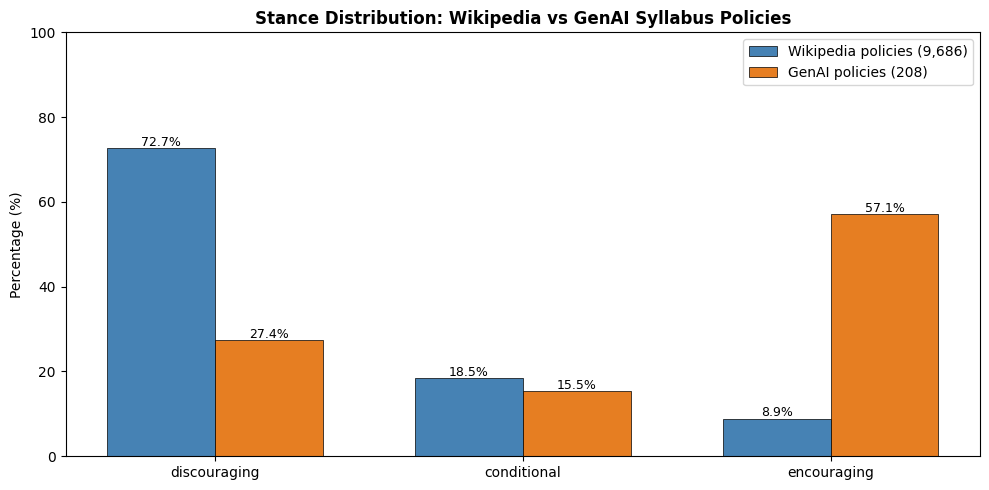

Figure saved!


In [7]:
# Cell 7 — Wikipedia vs GenAI Comparison Plot

# Wikipedia distribution from notebook 07 (weighted)
wiki_dist = {
    'discouraging': 72.7,
    'conditional' : 18.5,
    'encouraging' :  8.9
}

# GenAI sentence-level distribution
genai_dist = {}
for stance in LABELS:
    pct = (df_sentences['stance'] == stance).sum() / len(df_sentences) * 100
    genai_dist[stance] = pct

print('Wikipedia stance distribution (weighted):')
for s, p in wiki_dist.items():
    print(f'  {s:<15}: {p:.1f}%')
print()
print('GenAI stance distribution (sentence-level):')
for s, p in genai_dist.items():
    print(f'  {s:<15}: {p:.1f}%')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x  = np.arange(len(LABELS))
w  = 0.35
colors = ['#4682b4', '#e67e22']

b1 = ax.bar(x - w/2, [wiki_dist[s]  for s in LABELS], w,
            label='Wikipedia policies (9,686)',
            color=colors[0], edgecolor='black', linewidth=0.5)
b2 = ax.bar(x + w/2, [genai_dist[s] for s in LABELS], w,
            label='GenAI policies (208)',
            color=colors[1], edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel('Percentage (%)')
ax.set_title('Stance Distribution: Wikipedia vs GenAI Syllabus Policies',
             fontweight='bold', fontsize=12)
ax.legend()
ax.set_ylim(0, 100)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}08_wiki_vs_genai_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

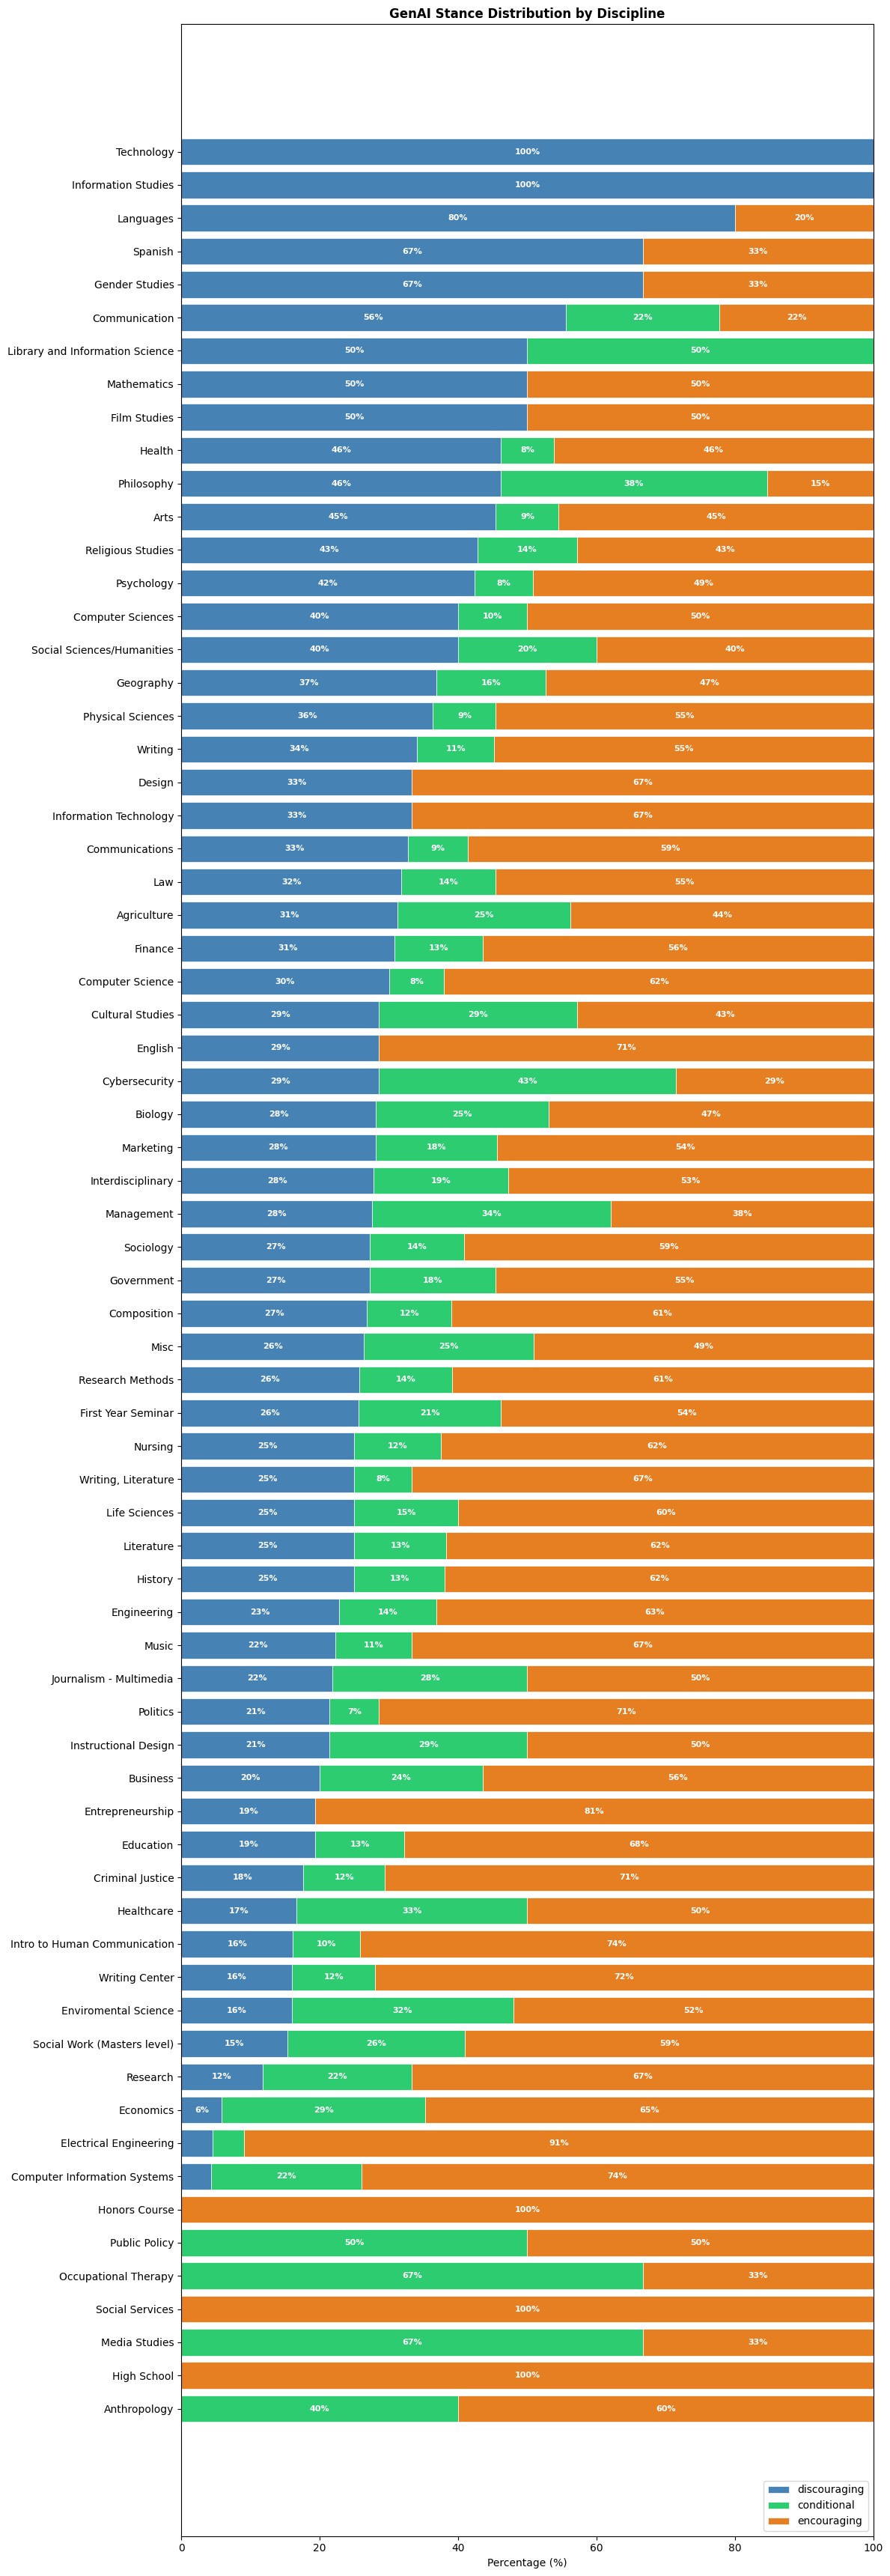

Figure saved!


In [8]:
# Cell 8 — Discipline Breakdown Plot
# Keep only disciplines with >= 3 sentences for reliability
discipline_counts = df_sentences['discipline'].value_counts()
valid_disciplines = discipline_counts[discipline_counts >= 3].index
df_disc_filtered  = df_sentences[df_sentences['discipline'].isin(valid_disciplines)]

df_disc_plot = df_disc_filtered.groupby(['discipline', 'stance']).size().unstack(fill_value=0)
df_disc_plot = df_disc_plot.div(df_disc_plot.sum(axis=1), axis=0) * 100

# Sort by discouraging % descending
df_disc_plot = df_disc_plot.sort_values('discouraging', ascending=True)

fig, ax = plt.subplots(figsize=(12, max(6, len(df_disc_plot) * 0.5)))
colors  = {'discouraging': '#4682b4', 'conditional': '#2ecc71', 'encouraging': '#e67e22'}

left = np.zeros(len(df_disc_plot))
for stance in LABELS:
    if stance in df_disc_plot.columns:
        vals = df_disc_plot[stance].values
        bars = ax.barh(df_disc_plot.index, vals, left=left,
                       label=stance, color=colors[stance],
                       edgecolor='white', linewidth=0.5)
        for i, (v, l) in enumerate(zip(vals, left)):
            if v > 5:
                ax.text(l + v/2, i, f'{v:.0f}%',
                        ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        left += vals

ax.set_xlabel('Percentage (%)')
ax.set_title('GenAI Stance Distribution by Discipline',
             fontweight='bold', fontsize=12)
ax.legend(loc='lower right')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}08_genai_discipline_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

In [9]:
# Cell 9 — Save Results + Summary

# Save sentence-level results
sent_path = f'{RESULTS_DIR}08_genai_sentences_classified.csv'
df_sentences.to_csv(sent_path, index=False)

# Save policy-level results
policy_path = f'{RESULTS_DIR}08_genai_policy_level.csv'
df_policy_level.to_csv(policy_path, index=False)

# Save discipline breakdown
disc_path = f'{RESULTS_DIR}08_genai_discipline_breakdown.csv'
df_discipline_pct.to_csv(disc_path)

print('=' * 60)
print('  NOTEBOOK 08 COMPLETE — SUMMARY')
print('=' * 60)
print()
print(f'Input policies         : {len(df_raw)}')
print(f'AI-mentioning sentences: {len(df_sentences)}')
print(f'Avg sentences/policy   : {len(df_sentences)/len(df_raw):.1f}')
print()
print('GenAI Stance Distribution (sentence-level):')
for stance in LABELS:
    n   = (df_sentences['stance'] == stance).sum()
    pct = n / len(df_sentences) * 100
    print(f'  {stance:<15}: {n:,} ({pct:.1f}%)')
print()
print('Wikipedia vs GenAI shift:')
for stance in LABELS:
    genai_pct = (df_sentences['stance'] == stance).sum() / len(df_sentences) * 100
    diff      = genai_pct - wiki_dist[stance]
    direction = 'higher' if diff > 0 else 'lower'
    print(f'  {stance:<15}: {abs(diff):.1f}% {direction} in GenAI vs Wikipedia')
print()
low_conf = (df_sentences['confidence'] < 0.70).sum()
print(f'Low confidence (<0.70) : {low_conf} ({low_conf/len(df_sentences)*100:.1f}%)')
print()
print('Files saved:')
for path in [sent_path, policy_path, disc_path]:
    status = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  [{status}] {path}')
print()
print('Figures saved:')
for fig in ['08_wiki_vs_genai_comparison.png', '08_genai_discipline_breakdown.png']:
    p      = f'{ANALYSIS_DIR}{fig}'
    status = 'OK' if os.path.exists(p) else 'MISSING'
    print(f'  [{status}] {fig}')
print()
print('Next: paper draft')
print('=' * 60)

  NOTEBOOK 08 COMPLETE — SUMMARY

Input policies         : 209
AI-mentioning sentences: 2076
Avg sentences/policy   : 9.9

GenAI Stance Distribution (sentence-level):
  discouraging   : 569 (27.4%)
  conditional    : 321 (15.5%)
  encouraging    : 1,186 (57.1%)

Wikipedia vs GenAI shift:
  discouraging   : 45.3% lower in GenAI vs Wikipedia
  conditional    : 3.0% lower in GenAI vs Wikipedia
  encouraging    : 48.2% higher in GenAI vs Wikipedia

Low confidence (<0.70) : 946 (45.6%)

Files saved:
  [OK] /content/drive/MyDrive/stance_detection/results/08_genai_sentences_classified.csv
  [OK] /content/drive/MyDrive/stance_detection/results/08_genai_policy_level.csv
  [OK] /content/drive/MyDrive/stance_detection/results/08_genai_discipline_breakdown.csv

Figures saved:
  [OK] 08_wiki_vs_genai_comparison.png
  [OK] 08_genai_discipline_breakdown.png

Next: paper draft


In [10]:
# Cell 10 — Per-Discipline Breakdown (printed + plotted)

print('=' * 60)
print('  GenAI STANCE BY DISCIPLINE')
print('=' * 60)
print()

# Count sentences per discipline
discipline_counts = df_sentences['discipline'].value_counts()

# Build summary table
rows = []
for discipline in discipline_counts.index:
    df_d    = df_sentences[df_sentences['discipline'] == discipline]
    n_total = len(df_d)
    n_disc  = (df_d['stance'] == 'discouraging').sum()
    n_cond  = (df_d['stance'] == 'conditional').sum()
    n_enc   = (df_d['stance'] == 'encouraging').sum()
    rows.append({
        'discipline'    : discipline,
        'n_sentences'   : n_total,
        'pct_disc'      : n_disc / n_total * 100,
        'pct_cond'      : n_cond / n_total * 100,
        'pct_enc'       : n_enc  / n_total * 100,
        'dominant_stance': 'discouraging' if n_disc >= n_cond and n_disc >= n_enc
                           else 'conditional' if n_cond >= n_enc
                           else 'encouraging'
    })

df_summary = pd.DataFrame(rows).sort_values('pct_enc', ascending=False)

# Print table
print(f'{"Discipline":<30} {"N":>5} {"Disc%":>7} {"Cond%":>7} {"Enc%":>7} {"Dominant":>15}')
print('-' * 75)
for _, row in df_summary.iterrows():
    print(f'{row["discipline"]:<30} {row["n_sentences"]:>5} '
          f'{row["pct_disc"]:>6.1f}% {row["pct_cond"]:>6.1f}% '
          f'{row["pct_enc"]:>6.1f}% {row["dominant_stance"]:>15}')

print()
print('--- KEY FINDINGS ---')
most_enc  = df_summary.iloc[0]
most_disc = df_summary.sort_values('pct_disc', ascending=False).iloc[0]
most_cond = df_summary.sort_values('pct_cond', ascending=False).iloc[0]
print(f'Most encouraging : {most_enc["discipline"]} ({most_enc["pct_enc"]:.1f}%)')
print(f'Most discouraging: {most_disc["discipline"]} ({most_disc["pct_disc"]:.1f}%)')
print(f'Most conditional : {most_cond["discipline"]} ({most_cond["pct_cond"]:.1f}%)')

# Save summary table
summary_path = f'{RESULTS_DIR}08_genai_discipline_summary.csv'
df_summary.to_csv(summary_path, index=False)
print()
print(f'Discipline summary saved: {summary_path}')

  GenAI STANCE BY DISCIPLINE

Discipline                         N   Disc%   Cond%    Enc%        Dominant
---------------------------------------------------------------------------
Social Services                    4    0.0%    0.0%  100.0%     encouraging
High School                        3    0.0%    0.0%  100.0%     encouraging
Social Sciences                    1    0.0%    0.0%  100.0%     encouraging
Information Science                2    0.0%    0.0%  100.0%     encouraging
Math                               1    0.0%    0.0%  100.0%     encouraging
Honors Course                      4    0.0%    0.0%  100.0%     encouraging
Electrical Engineering            22    4.5%    4.5%   90.9%     encouraging
Entrepreneurship                  31   19.4%    0.0%   80.6%     encouraging
Intro to Human Communication      31   16.1%    9.7%   74.2%     encouraging
Computer Information Systems      23    4.3%   21.7%   73.9%     encouraging
Writing Center                    25   16.0%   

In [11]:
# Cell 11 — Institution-level Analysis
print('=' * 60)
print('  GenAI STANCE BY INSTITUTION')
print('=' * 60)
print()

# Only keep institutions with >= 10 sentences
inst_counts = df_sentences['institution'].value_counts()
valid_insts = inst_counts[inst_counts >= 10].index
df_inst     = df_sentences[df_sentences['institution'].isin(valid_insts)]

rows = []
for inst in valid_insts:
    df_i    = df_inst[df_inst['institution'] == inst]
    n_total = len(df_i)
    n_disc  = (df_i['stance'] == 'discouraging').sum()
    n_cond  = (df_i['stance'] == 'conditional').sum()
    n_enc   = (df_i['stance'] == 'encouraging').sum()
    rows.append({
        'institution'   : inst,
        'n_sentences'   : n_total,
        'pct_disc'      : n_disc / n_total * 100,
        'pct_cond'      : n_cond / n_total * 100,
        'pct_enc'       : n_enc  / n_total * 100,
        'dominant_stance': 'discouraging' if n_disc >= n_cond and n_disc >= n_enc
                           else 'conditional' if n_cond >= n_enc
                           else 'encouraging'
    })

df_inst_summary = pd.DataFrame(rows).sort_values('pct_enc', ascending=False)

print(f'{"Institution":<40} {"N":>5} {"Disc%":>7} {"Cond%":>7} {"Enc%":>7} {"Dominant":>15}')
print('-' * 85)
for _, row in df_inst_summary.iterrows():
    print(f'{row["institution"]:<40} {row["n_sentences"]:>5} '
          f'{row["pct_disc"]:>6.1f}% {row["pct_cond"]:>6.1f}% '
          f'{row["pct_enc"]:>6.1f}% {row["dominant_stance"]:>15}')

print()
print('--- KEY FINDINGS ---')
most_enc  = df_inst_summary.iloc[0]
most_disc = df_inst_summary.sort_values('pct_disc', ascending=False).iloc[0]
print(f'Most encouraging : {most_enc["institution"]} ({most_enc["pct_enc"]:.1f}%)')
print(f'Most discouraging: {most_disc["institution"]} ({most_disc["pct_disc"]:.1f}%)')

# Save
inst_path = f'{RESULTS_DIR}08_genai_institution_summary.csv'
df_inst_summary.to_csv(inst_path, index=False)
print(f'\nInstitution summary saved: {inst_path}')

  GenAI STANCE BY INSTITUTION

Institution                                  N   Disc%   Cond%    Enc%        Dominant
-------------------------------------------------------------------------------------
Olympic College                             12    0.0%    0.0%  100.0%     encouraging
Harvey Mudd College                         22    4.5%    4.5%   90.9%     encouraging
Colorado Mesa University                    25   12.0%    0.0%   88.0%     encouraging
University of Florida                       31   19.4%    0.0%   80.6%     encouraging
University of Arizona                       18   16.7%    5.6%   77.8%     encouraging
Berry College                               22   18.2%    4.5%   77.3%     encouraging
Colgate University                          17   17.6%    5.9%   76.5%     encouraging
Michigan Technological University           16   18.8%    6.2%   75.0%     encouraging
DePaul University                           12   25.0%    0.0%   75.0%     encouraging
Lewis Univers

  POLICY LENGTH VS STANCE

Word count per sentence by stance:

Stance             Mean  Median     Std   Min   Max
---------------------------------------------
discouraging       25.5    22.0    14.9     3   109
conditional        23.6    22.0    10.2     5    85
encouraging        22.4    20.0    19.3     1   526

Full policy word count by dominant stance:

Stance             Mean  Median     Std     N
----------------------------------------
discouraging      203.8   141.0   168.6    52
conditional       184.2   155.0   159.0    15
encouraging       402.4   317.0   341.8   141



/tmp/ipykernel_2707/3454386338.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(data_sent, patch_artist=True, labels=LABELS)
/tmp/ipykernel_2707/3454386338.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data_policy, patch_artist=True, labels=LABELS)


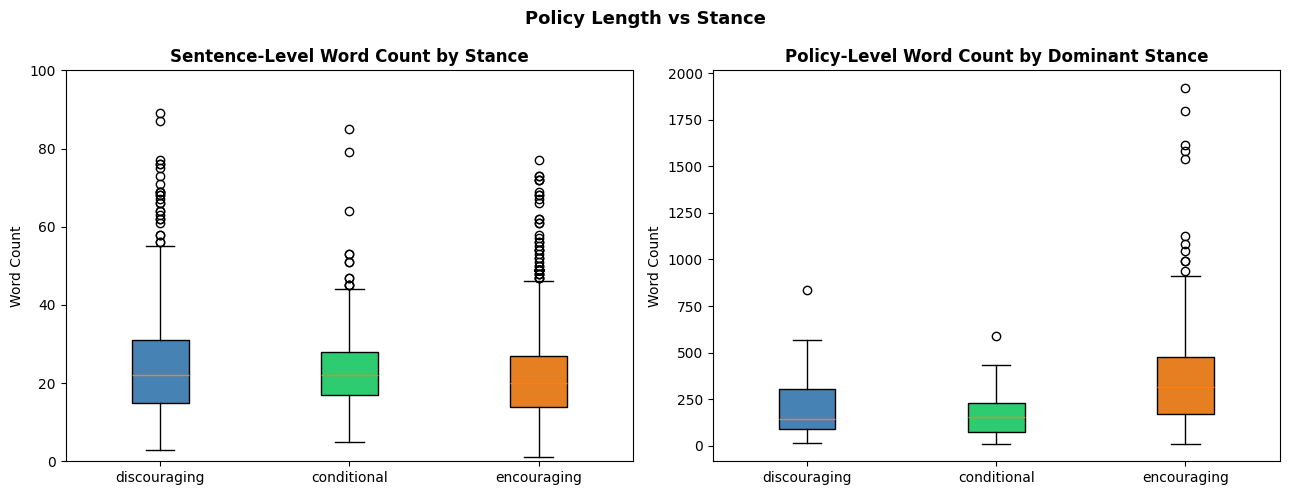

Figure saved!


In [12]:
# Cell 12 — Policy Length vs Stance
print('=' * 60)
print('  POLICY LENGTH VS STANCE')
print('=' * 60)
print()

# Sentence-level word count
df_sentences['word_count'] = df_sentences['sentence'].apply(lambda x: len(x.split()))

# Stats per stance
print('Word count per sentence by stance:')
print()
print(f'{"Stance":<15} {"Mean":>7} {"Median":>7} {"Std":>7} {"Min":>5} {"Max":>5}')
print('-' * 45)
for stance in LABELS:
    df_s = df_sentences[df_sentences['stance'] == stance]['word_count']
    print(f'{stance:<15} {df_s.mean():>7.1f} {df_s.median():>7.1f} '
          f'{df_s.std():>7.1f} {df_s.min():>5} {df_s.max():>5}')

print()

# Policy-level word count (full policy text)
df_raw['word_count'] = df_raw['Policy in the Syllabus'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)

# Merge policy-level stance (majority vote) back to raw
df_merge = df_policy_level[['course', 'stance_policy']].copy()
df_merge.columns = ['Course', 'stance_policy']
df_raw_merged = df_raw.merge(df_merge, on='Course', how='left')

print('Full policy word count by dominant stance:')
print()
print(f'{"Stance":<15} {"Mean":>7} {"Median":>7} {"Std":>7} {"N":>5}')
print('-' * 40)
for stance in LABELS:
    df_s = df_raw_merged[df_raw_merged['stance_policy'] == stance]['word_count']
    if len(df_s) > 0:
        print(f'{stance:<15} {df_s.mean():>7.1f} {df_s.median():>7.1f} '
              f'{df_s.std():>7.1f} {len(df_s):>5}')

print()

# Plot — boxplot of sentence word counts by stance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — sentence level
colors = {'discouraging': '#4682b4', 'conditional': '#2ecc71', 'encouraging': '#e67e22'}
data_sent = [df_sentences[df_sentences['stance'] == s]['word_count'].values
             for s in LABELS]
bp1 = axes[0].boxplot(data_sent, patch_artist=True, labels=LABELS)
for patch, stance in zip(bp1['boxes'], LABELS):
    patch.set_facecolor(colors[stance])
axes[0].set_title('Sentence-Level Word Count by Stance', fontweight='bold')
axes[0].set_ylabel('Word Count')
axes[0].set_ylim(0, 100)

# Right — policy level
data_policy = [df_raw_merged[df_raw_merged['stance_policy'] == s]['word_count'].values
               for s in LABELS]
bp2 = axes[1].boxplot(data_policy, patch_artist=True, labels=LABELS)
for patch, stance in zip(bp2['boxes'], LABELS):
    patch.set_facecolor(colors[stance])
axes[1].set_title('Policy-Level Word Count by Dominant Stance', fontweight='bold')
axes[1].set_ylabel('Word Count')

plt.suptitle('Policy Length vs Stance', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}08_policy_length_vs_stance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

  CONFIDENCE BY DISCIPLINE

Discipline                         N  Avg Conf  % Low Conf
----------------------------------------------------------
Economics                         17     0.816       17.6%
Entrepreneurship                  31     0.813       22.6%
Electrical Engineering            22     0.811       27.3%
Writing Center                    25     0.791       32.0%
Politics                          14     0.788       35.7%
Education                         93     0.788       31.2%
Composition                       41     0.779       36.6%
Life Sciences                     20     0.773       30.0%
Writing, Literature               12     0.765       50.0%
Law                               44     0.763       38.6%
Physical Sciences                 11     0.763       45.5%
Engineering                       57     0.759       36.8%
Literature                        68     0.758       32.4%
Business                          85     0.751       41.2%
Social Work (Masters level) 

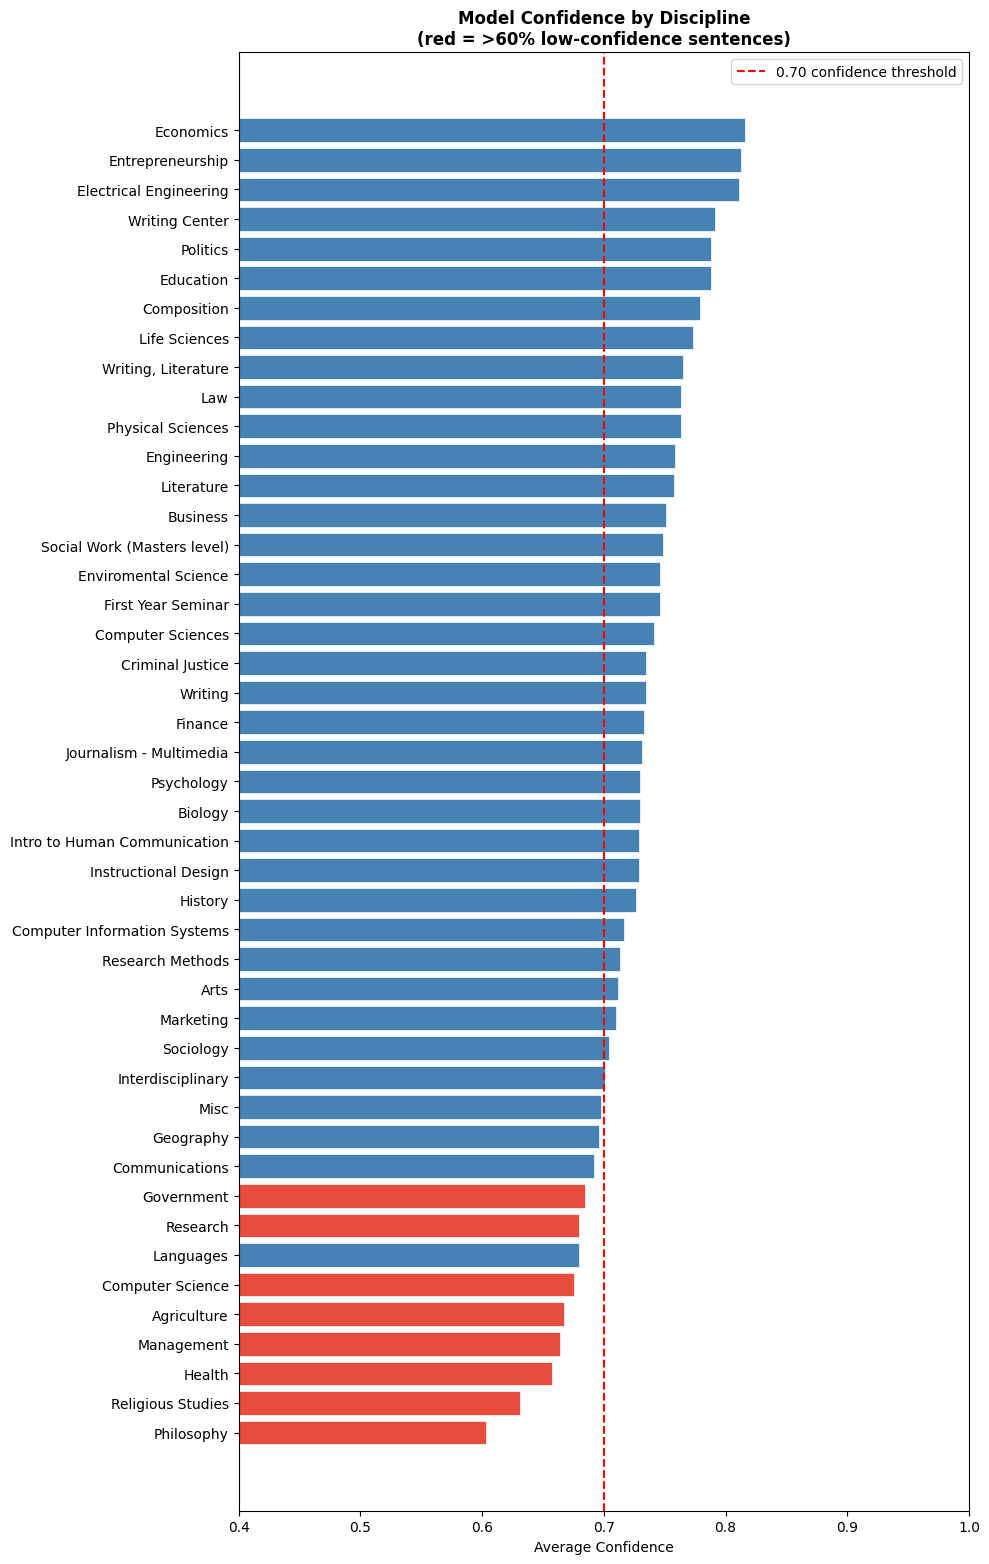

Figure saved!


In [13]:
# Cell 13 — Confidence by Discipline
print('=' * 60)
print('  CONFIDENCE BY DISCIPLINE')
print('=' * 60)
print()

# Only disciplines with >= 10 sentences
valid_discs = df_sentences['discipline'].value_counts()
valid_discs = valid_discs[valid_discs >= 10].index

rows = []
for disc in valid_discs:
    df_d     = df_sentences[df_sentences['discipline'] == disc]
    avg_conf = df_d['confidence'].mean()
    low_conf = (df_d['confidence'] < 0.70).sum()
    pct_low  = low_conf / len(df_d) * 100
    rows.append({
        'discipline' : disc,
        'n_sentences': len(df_d),
        'avg_conf'   : avg_conf,
        'pct_low_conf': pct_low
    })

df_conf = pd.DataFrame(rows).sort_values('avg_conf', ascending=False)

print(f'{"Discipline":<30} {"N":>5} {"Avg Conf":>9} {"% Low Conf":>11}')
print('-' * 58)
for _, row in df_conf.iterrows():
    flag = ' ⚠' if row['pct_low_conf'] > 60 else ''
    print(f'{row["discipline"]:<30} {row["n_sentences"]:>5} '
          f'{row["avg_conf"]:>9.3f} {row["pct_low_conf"]:>10.1f}%{flag}')

print()
print('--- KEY FINDINGS ---')
highest = df_conf.iloc[0]
lowest  = df_conf.iloc[-1]
most_uncertain = df_conf.sort_values('pct_low_conf', ascending=False).iloc[0]
print(f'Highest confidence: {highest["discipline"]} ({highest["avg_conf"]:.3f})')
print(f'Lowest confidence : {lowest["discipline"]} ({lowest["avg_conf"]:.3f})')
print(f'Most uncertain    : {most_uncertain["discipline"]} ({most_uncertain["pct_low_conf"]:.1f}% low conf)')
print()

# Plot — horizontal bar chart of avg confidence by discipline
df_conf_plot = df_conf.sort_values('avg_conf', ascending=True)
colors_conf  = ['#e74c3c' if p > 60 else '#4682b4'
                for p in df_conf_plot['pct_low_conf']]

fig, ax = plt.subplots(figsize=(10, max(6, len(df_conf_plot) * 0.35)))
bars = ax.barh(df_conf_plot['discipline'], df_conf_plot['avg_conf'],
               color=colors_conf, edgecolor='white', linewidth=0.5)
ax.axvline(x=0.70, color='red', linestyle='--', linewidth=1.5,
           label='0.70 confidence threshold')
ax.set_xlabel('Average Confidence')
ax.set_title('Model Confidence by Discipline\n(red = >60% low-confidence sentences)',
             fontweight='bold', fontsize=12)
ax.set_xlim(0.4, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}08_confidence_by_discipline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

In [14]:
# Cell 14 — Conditional Stance Deep Dive
from collections import Counter
import re

print('=' * 60)
print('  CONDITIONAL STANCE DEEP DIVE')
print('=' * 60)
print()

# Isolate conditional sentences
df_cond = df_sentences[df_sentences['stance'] == 'conditional'].copy()
print(f'Total conditional sentences: {len(df_cond)}')
print()

# --- 1. Condition keywords --- #
CONDITION_KEYWORDS = {
    'disclosure'  : ['disclose', 'disclosure', 'transparency', 'transparent', 'acknowledge'],
    'citation'    : ['cite', 'citation', 'reference', 'attribute', 'attribution'],
    'permission'  : ['permission', 'permitted', 'allow', 'allowed', 'approve', 'approved'],
    'limitation'  : ['only', 'limited', 'restrict', 'restriction', 'specific', 'certain'],
    'integrity'   : ['academic integrity', 'plagiarism', 'dishonesty', 'misconduct', 'honest'],
    'tool_specific': ['chatgpt', 'gpt', 'dall-e', 'copilot', 'gemini', 'bard', 'claude'],
    'submission'  : ['submit', 'submission', 'turn in', 'upload', 'assignment'],
    'instructor'  : ['instructor', 'professor', 'teacher', 'faculty', 'ask me', 'consult'],
}

print('Condition keyword frequency in conditional sentences:')
print()
print(f'{"Category":<15} {"Count":>7} {"% of Cond":>10}')
print('-' * 35)
keyword_counts = {}
for category, keywords in CONDITION_KEYWORDS.items():
    count = 0
    for _, row in df_cond.iterrows():
        s = row['sentence'].lower()
        if any(kw in s for kw in keywords):
            count += 1
    keyword_counts[category] = count
    pct = count / len(df_cond) * 100
    print(f'{category:<15} {count:>7} {pct:>9.1f}%')

print()

# --- 2. Most common words in conditional sentences --- #
from collections import Counter
import re

STOPWORDS = set([
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to',
    'for', 'of', 'with', 'by', 'from', 'is', 'are', 'was', 'were',
    'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did',
    'will', 'would', 'could', 'should', 'may', 'might', 'must', 'shall',
    'this', 'that', 'these', 'those', 'it', 'its', 'you', 'your',
    'i', 'my', 'we', 'our', 'they', 'their', 'as', 'if', 'not',
    'use', 'used', 'using', 'any', 'all', 'such', 'ai', 'generative'
])

all_words = []
for sent in df_cond['sentence']:
    words = re.findall(r'\b[a-z]+\b', sent.lower())
    all_words.extend([w for w in words if w not in STOPWORDS and len(w) > 3])

word_freq = Counter(all_words).most_common(20)
print('Top 20 words in conditional sentences:')
print()
print(f'{"Word":<20} {"Count":>7}')
print('-' * 28)
for word, count in word_freq:
    print(f'{word:<20} {count:>7}')

print()

# --- 3. Sample conditional sentences --- #
print('Sample conditional sentences (high confidence):')
print()
df_cond_high = df_cond.sort_values('confidence', ascending=False).head(10)
for i, (_, row) in enumerate(df_cond_high.iterrows(), 1):
    print(f'{i}. [{row["discipline"]}] (conf={row["confidence"]:.3f})')
    print(f'   {row["sentence"][:150]}')
    print()

# --- 4. Conditional by discipline --- #
print('Conditional sentence rate by discipline (N>=10):')
print()
print(f'{"Discipline":<30} {"Total":>6} {"Cond":>6} {"Cond%":>7}')
print('-' * 52)
valid = df_sentences['discipline'].value_counts()
valid = valid[valid >= 10].index
rows  = []
for disc in valid:
    df_d   = df_sentences[df_sentences['discipline'] == disc]
    n_cond = (df_d['stance'] == 'conditional').sum()
    pct    = n_cond / len(df_d) * 100
    rows.append({'discipline': disc, 'total': len(df_d),
                 'n_cond': n_cond, 'pct_cond': pct})

df_cond_disc = pd.DataFrame(rows).sort_values('pct_cond', ascending=False)
for _, row in df_cond_disc.iterrows():
    if row['pct_cond'] > 0:
        print(f'{row["discipline"]:<30} {row["total"]:>6} '
              f'{row["n_cond"]:>6} {row["pct_cond"]:>6.1f}%')

# Save
cond_path = f'{RESULTS_DIR}08_conditional_analysis.csv'
df_cond.to_csv(cond_path, index=False)
print()
print(f'Conditional sentences saved: {cond_path}')

  CONDITIONAL STANCE DEEP DIVE

Total conditional sentences: 321

Condition keyword frequency in conditional sentences:

Category          Count  % of Cond
-----------------------------------
disclosure           23       7.2%
citation             60      18.7%
permission           17       5.3%
limitation           35      10.9%
integrity            25       7.8%
tool_specific        16       5.0%
submission           45      14.0%
instructor           20       6.2%

Top 20 words in conditional sentences:

Word                   Count
----------------------------
work                      69
tools                     68
sources                   58
information               46
generated                 43
content                   34
students                  34
academic                  31
data                      30
writing                   25
other                     24
tool                      23
when                      22
text                      21
cite                   

  CO-OCCURRENCE / KEYWORD ANALYSIS

Tool mention frequency by stance:

Tool          Total   Disc%   Cond%    Enc%
------------------------------------------
ChatGPT         317   31.2%    4.7%   64.0%
GPT             199   32.2%    6.5%   61.3%
Copilot          24   29.2%    4.2%   66.7%
Gemini           18   16.7%    0.0%   83.3%
DALL-E           27   25.9%    7.4%   66.7%
Bard             23   17.4%    0.0%   82.6%
Claude           25   28.0%    0.0%   72.0%
Generic AI      769   23.9%   14.2%   61.9%

Framing word frequency by stance:

Framing           Disc%   Cond%    Enc%
--------------------------------------
prohibition       43.4%   36.1%   12.0%
permission        29.3%   39.6%   26.6%
caution            6.5%   17.1%    3.8%
academic_int      29.7%   10.0%   11.0%
learning           8.4%   10.9%   21.7%
productivity       6.3%   10.3%   14.3%

Blanket ban vs specific tool mentions:

Blanket ban language  : 83 sentences (4.0%)
Specific tool mention : 319 sentences (15.4%)

Sta

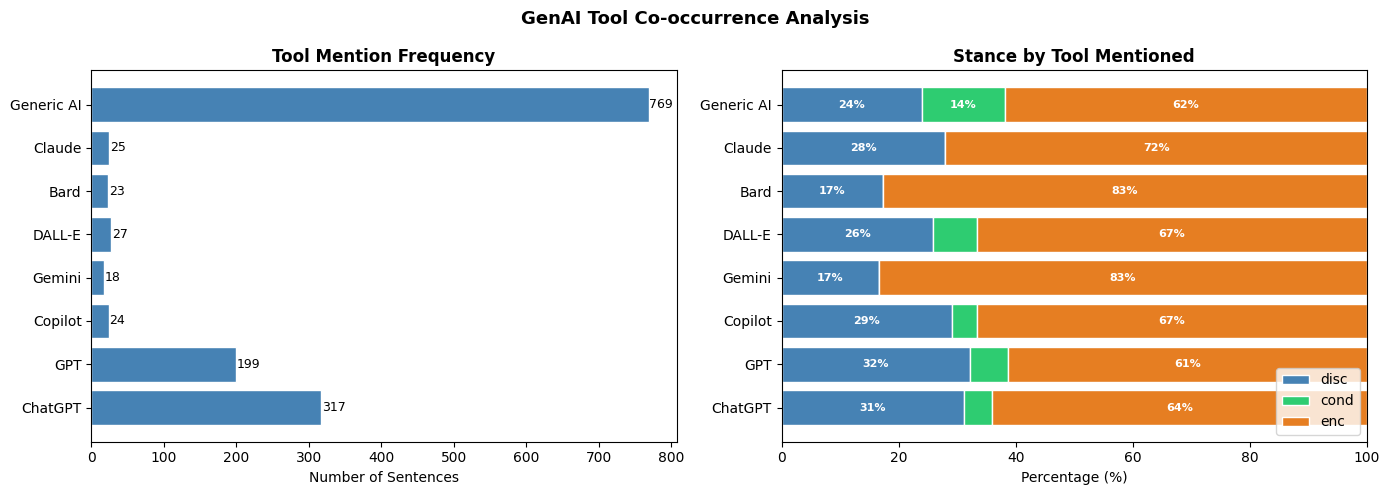

Figure saved!
Tool analysis saved: /content/drive/MyDrive/stance_detection/results/08_tool_cooccurrence.csv


In [15]:
# Cell 15 — Co-occurrence / Keyword Analysis
print('=' * 60)
print('  CO-OCCURRENCE / KEYWORD ANALYSIS')
print('=' * 60)
print()

# --- 1. Tool-specific mentions by stance --- #
TOOL_KEYWORDS = {
    'ChatGPT'    : ['chatgpt', 'chat gpt'],
    'GPT'        : ['gpt-4', 'gpt-3', 'gpt4', 'gpt3', 'gpt '],
    'Copilot'    : ['copilot'],
    'Gemini'     : ['gemini'],
    'DALL-E'     : ['dall-e', 'dalle'],
    'Bard'       : ['bard'],
    'Claude'     : ['claude'],
    'Generic AI' : ['artificial intelligence', 'generative ai',
                    'genai', 'gai', 'ai tools', 'ai tool',
                    'large language model', 'llm'],
}

print('Tool mention frequency by stance:')
print()
print(f'{"Tool":<12} {"Total":>6} {"Disc%":>7} {"Cond%":>7} {"Enc%":>7}')
print('-' * 42)

tool_rows = []
for tool, keywords in TOOL_KEYWORDS.items():
    mask = df_sentences['sentence'].apply(
        lambda x: any(kw in x.lower() for kw in keywords)
    )
    df_tool = df_sentences[mask]
    if len(df_tool) == 0:
        continue
    n_total = len(df_tool)
    n_disc  = (df_tool['stance'] == 'discouraging').sum()
    n_cond  = (df_tool['stance'] == 'conditional').sum()
    n_enc   = (df_tool['stance'] == 'encouraging').sum()
    tool_rows.append({
        'tool'   : tool,
        'n_total': n_total,
        'pct_disc': n_disc / n_total * 100,
        'pct_cond': n_cond / n_total * 100,
        'pct_enc' : n_enc  / n_total * 100,
    })
    print(f'{tool:<12} {n_total:>6} {n_disc/n_total*100:>6.1f}% '
          f'{n_cond/n_total*100:>6.1f}% {n_enc/n_total*100:>6.1f}%')

print()

# --- 2. Framing words by stance --- #
FRAMING = {
    'prohibition' : ['not', 'never', 'prohibited', 'forbidden', 'ban',
                     'banned', 'disallow', 'disallowed', 'unacceptable'],
    'permission'  : ['may', 'can', 'allowed', 'permitted', 'welcome',
                     'encouraged', 'feel free', 'okay', 'acceptable'],
    'caution'     : ['caution', 'careful', 'aware', 'warning', 'risk',
                     'concern', 'bias', 'inaccurate', 'limitation'],
    'academic_int': ['integrity', 'plagiarism', 'dishonesty', 'misconduct',
                     'cheating', 'violation', 'policy'],
    'learning'    : ['learn', 'learning', 'understand', 'skill', 'skills',
                     'develop', 'growth', 'educational'],
    'productivity': ['efficient', 'efficiency', 'productivity', 'save time',
                     'faster', 'assist', 'assistance', 'help'],
}

print('Framing word frequency by stance:')
print()
print(f'{"Framing":<15} {"Disc%":>7} {"Cond%":>7} {"Enc%":>7}')
print('-' * 38)

for framing, keywords in FRAMING.items():
    counts = {}
    for stance in LABELS:
        df_s  = df_sentences[df_sentences['stance'] == stance]
        count = df_s['sentence'].apply(
            lambda x: any(kw in x.lower() for kw in keywords)
        ).sum()
        counts[stance] = count / len(df_s) * 100
    print(f'{framing:<15} {counts["discouraging"]:>6.1f}% '
          f'{counts["conditional"]:>6.1f}% {counts["encouraging"]:>6.1f}%')

print()

# --- 3. Blanket ban vs specific tool ban --- #
print('Blanket ban vs specific tool mentions:')
print()
blanket = df_sentences['sentence'].apply(
    lambda x: any(kw in x.lower() for kw in
                  ['any ai', 'all ai', 'no ai', 'artificial intelligence is not',
                   'ai is not', 'do not use ai', 'not use ai', 'not allowed'])
)
specific = df_sentences['sentence'].apply(
    lambda x: any(kw in x.lower() for kw in
                  ['chatgpt', 'gpt-4', 'gpt-3', 'dall-e', 'copilot', 'gemini'])
)

print(f'Blanket ban language  : {blanket.sum()} sentences '
      f'({blanket.sum()/len(df_sentences)*100:.1f}%)')
print(f'Specific tool mention : {specific.sum()} sentences '
      f'({specific.sum()/len(df_sentences)*100:.1f}%)')
print()

# Stance breakdown for blanket ban sentences
df_blanket = df_sentences[blanket]
if len(df_blanket) > 0:
    print('Stance of blanket-ban sentences:')
    for stance in LABELS:
        n   = (df_blanket['stance'] == stance).sum()
        pct = n / len(df_blanket) * 100
        print(f'  {stance:<15}: {n} ({pct:.1f}%)')
print()

# Stance breakdown for specific tool sentences
df_specific = df_sentences[specific]
if len(df_specific) > 0:
    print('Stance of specific-tool sentences:')
    for stance in LABELS:
        n   = (df_specific['stance'] == stance).sum()
        pct = n / len(df_specific) * 100
        print(f'  {stance:<15}: {n} ({pct:.1f}%)')
print()

# --- 4. Plot — tool mentions by stance --- #
df_tools = pd.DataFrame(tool_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — tool frequency
axes[0].barh(df_tools['tool'], df_tools['n_total'],
             color='#4682b4', edgecolor='white')
axes[0].set_xlabel('Number of Sentences')
axes[0].set_title('Tool Mention Frequency', fontweight='bold')
for i, (_, row) in enumerate(df_tools.iterrows()):
    axes[0].text(row['n_total'] + 1, i, str(row['n_total']),
                 va='center', fontsize=9)

# Right — stance breakdown per tool (stacked bar)
colors = {'pct_disc': '#4682b4', 'pct_cond': '#2ecc71', 'pct_enc': '#e67e22'}
left   = np.zeros(len(df_tools))
for col, color in colors.items():
    label = col.replace('pct_', '')
    axes[1].barh(df_tools['tool'], df_tools[col], left=left,
                 color=color, label=label, edgecolor='white')
    for i, (v, l) in enumerate(zip(df_tools[col], left)):
        if v > 8:
            axes[1].text(l + v/2, i, f'{v:.0f}%',
                         ha='center', va='center',
                         fontsize=8, color='white', fontweight='bold')
    left += df_tools[col].values

axes[1].set_xlabel('Percentage (%)')
axes[1].set_title('Stance by Tool Mentioned', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].set_xlim(0, 100)

plt.suptitle('GenAI Tool Co-occurrence Analysis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}08_tool_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

# Save
tool_path = f'{RESULTS_DIR}08_tool_cooccurrence.csv'
pd.DataFrame(tool_rows).to_csv(tool_path, index=False)
print(f'Tool analysis saved: {tool_path}')

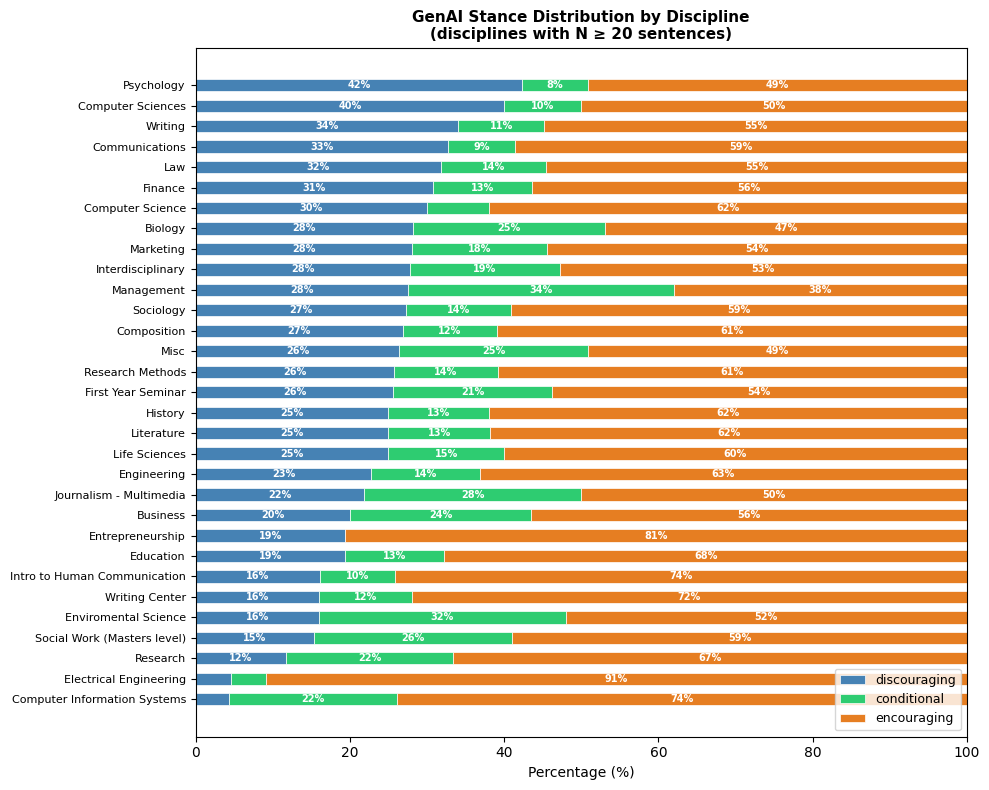

Figure saved!


In [6]:
# Regenerate discipline figure with N >= 20 filter
valid_discs = df_sentences['discipline'].value_counts()
valid_discs = valid_discs[valid_discs >= 20].index  # changed from 10 to 20
df_disc_filtered = df_sentences[df_sentences['discipline'].isin(valid_discs)]

df_disc_plot = df_disc_filtered.groupby(['discipline', 'stance']).size().unstack(fill_value=0)
df_disc_plot = df_disc_plot.div(df_disc_plot.sum(axis=1), axis=0) * 100
df_disc_plot = df_disc_plot.sort_values('discouraging', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))  # much smaller height
colors = {'discouraging': '#4682b4', 'conditional': '#2ecc71', 'encouraging': '#e67e22'}

left = np.zeros(len(df_disc_plot))
for stance in LABELS:
    if stance in df_disc_plot.columns:
        vals = df_disc_plot[stance].values
        bars = ax.barh(df_disc_plot.index, vals, left=left,
                       label=stance, color=colors[stance],
                       edgecolor='white', linewidth=0.5,
                       height=0.6)  # thinner bars
        for i, (v, l) in enumerate(zip(vals, left)):
            if v > 8:
                ax.text(l + v/2, i, f'{v:.0f}%',
                        ha='center', va='center',
                        fontsize=7, color='white', fontweight='bold')
        left += vals

ax.set_xlabel('Percentage (%)', fontsize=10)
ax.set_title('GenAI Stance Distribution by Discipline\n(disciplines with N \u2265 20 sentences)',
             fontweight='bold', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 100)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}08_genai_discipline_breakdown.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

In [5]:
# Reload saved results — skip sentence splitting and classification
df_sentences = pd.read_csv(f'{RESULTS_DIR}08_genai_sentences_classified.csv')
print(f'Loaded {len(df_sentences)} sentences')
print(df_sentences['stance'].value_counts())

Loaded 2076 sentences
stance
encouraging     1186
discouraging     569
conditional      321
Name: count, dtype: int64


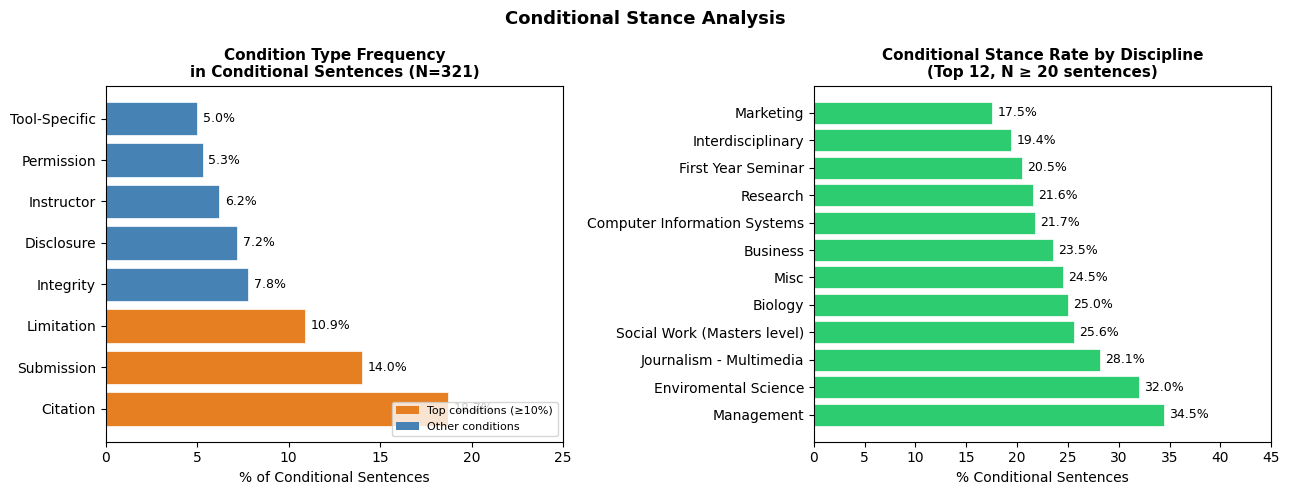

Figure saved!


In [7]:
# Conditional Analysis Figure
import matplotlib.pyplot as plt
import numpy as np

# --- Data from Cell 14 output ---
conditions = ['Citation', 'Submission', 'Limitation', 'Integrity',
              'Disclosure', 'Instructor', 'Permission', 'Tool-Specific']
percentages = [18.7, 14.0, 10.9, 7.8, 7.2, 6.2, 5.3, 5.0]

# Sort by percentage
sorted_pairs = sorted(zip(percentages, conditions), reverse=True)
percentages_sorted = [p for p, c in sorted_pairs]
conditions_sorted  = [c for p, c in sorted_pairs]

# Colors — highlight top 3
colors = ['#e67e22' if p >= 10 else '#4682b4' for p in percentages_sorted]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Condition type frequency ---
bars = axes[0].barh(conditions_sorted, percentages_sorted,
                    color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('% of Conditional Sentences', fontsize=10)
axes[0].set_title('Condition Type Frequency\nin Conditional Sentences (N=321)',
                  fontweight='bold', fontsize=11)
axes[0].set_xlim(0, 25)
for bar, pct in zip(bars, percentages_sorted):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{pct:.1f}%', va='center', fontsize=9)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e67e22', label='Top conditions (≥10%)'),
                   Patch(facecolor='#4682b4', label='Other conditions')]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

# --- Right: Conditional rate by discipline (top 10) ---
df_cond_disc = df_sentences.copy()
disc_counts  = df_cond_disc['discipline'].value_counts()
valid_discs  = disc_counts[disc_counts >= 20].index
df_cond_disc = df_cond_disc[df_cond_disc['discipline'].isin(valid_discs)]

cond_rates = []
for disc in valid_discs:
    df_d   = df_cond_disc[df_cond_disc['discipline'] == disc]
    n_cond = (df_d['stance'] == 'conditional').sum()
    pct    = n_cond / len(df_d) * 100
    cond_rates.append({'discipline': disc, 'pct_cond': pct})

import pandas as pd
df_cond_rates = pd.DataFrame(cond_rates).sort_values('pct_cond', ascending=False).head(12)

axes[1].barh(df_cond_rates['discipline'], df_cond_rates['pct_cond'],
             color='#2ecc71', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('% Conditional Sentences', fontsize=10)
axes[1].set_title('Conditional Stance Rate by Discipline\n(Top 12, N ≥ 20 sentences)',
                  fontweight='bold', fontsize=11)
axes[1].set_xlim(0, 45)
for i, (_, row) in enumerate(df_cond_rates.iterrows()):
    axes[1].text(row['pct_cond'] + 0.5, i,
                 f'{row["pct_cond"]:.1f}%', va='center', fontsize=9)

plt.suptitle('Conditional Stance Analysis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}08_conditional_analysis_fig.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')